# Notebook 05: Ampliación de la Evaluación - Incorporación de un Segundo LLM (Grupo de Control)

## 1. Motivación y Justificación Académica
En el experimento inicial (Notebook 04), se demostró empíricamente la superioridad de los sistemas RAG (Léxico y Semántico) frente a los modelos de lenguaje operando únicamente con su conocimiento paramétrico interno (SLM base y LLM Avanzado). 

Para comparar mas de un LLM y poder hacer una evaluacion final de la bateria de preguntas completa con el mejor sistema posible, en este cuaderno se evalua la bateria de preguntas inicial con un **segundo LLM**. 

El modelo seleccionado es **Qwen 3 32B**, una arquitectura radicalmente distinta a Llama, lo que garantiza la ausencia de sesgos familiares y consolida la hipótesis principal del trabajo: *la deficiencia en la precisión de datos factuales es inherente a los LLMs sin contexto externo, independientemente de su arquitectura o tamaño.*

## 2. Metodología de este Cuaderno
Para garantizar la integridad de los datos ya auditados, este proceso se ejecuta de manera independiente y en la nube (vía API), liberando así los recursos de hardware local (VRAM):

1. **Carga de Datos Auditados:** Importación del *dataset* `resultados_evaluacion_tfg_corregido.csv`, el cual contiene las 80 preguntas base y las respuestas de los 4 sistemas originales auditadas manualmente.
2. **Generación (Zero-Shot):** Interrogación al modelo **Qwen 3 32B** mediante la API de Groq, aplicando el mismo *System Prompt* restrictivo utilizado para Llama 3.
3. **Evaluación Automatizada (LLM-as-a-judge):** Uso de un modelo masivo (`openai/gpt-oss-120b`) configurado como juez estricto para dictaminar la veracidad de las nuevas respuestas frente al *Ground Truth* (Respuesta Esperada).
4. **Integración y Visualización:** Inserción de los nuevos resultados en el conjunto de datos y generación del gráfico comparativo final a 5 bandas.

In [ ]:
import os
import time
import pandas as pd
from tqdm import tqdm
from dotenv import load_dotenv
from langchain_groq import ChatGroq
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.output_parsers import StrOutputParser
from langchain_core.messages import SystemMessage, HumanMessage

# Cargar tu CSV corregido (manteniendo la configuración de Mac)
ruta_csv_corregido = "resultados_evaluacion_tfg_corregido.csv"
df_corregido = pd.read_csv(ruta_csv_corregido, sep=';')
df_corregido.columns = df_corregido.columns.str.strip()

print(f"Cargado el archivo base con {len(df_corregido)} preguntas evaluadas.")
df_corregido.head(3)

Cargado el archivo base con 80 preguntas evaluadas.


,Pregunta,Esperada,C1_SLM_Resp,C1_Eval,C2_LLM_Resp,C2_Eval,C3_BM25_Resp,C3_Eval,C4_VECT_Resp,C4_Eval
0,¿A cuanto llego a subir Trump los aranceles a ...,145%.,No puedo proporcionar información actualizada ...,INCORRECTO,Hasta un 25% en algunos productos.,INCORRECTO,100%,INCORRECTO,Los aranceles a China llegan a subir hasta el...,CORRECTO
1,¿Cuánto dinero perdió Elon Musk tras el anunci...,17.800 millones de dólares.,Elon Musk perdió aproximadamente $1.5 mil mill...,INCORRECTO,Perdió alrededor de $3.7 mil millones.,INCORRECTO,17.800 millones de dólares,CORRECTO,"Según el texto, Elon Musk perdió 17.800 millo...",CORRECTO
2,¿Qué opinó el Rey de España sobre los arancele...,No tengo información suficiente en mis archivos.,El Rey de España no ha expresado públicamente ...,INCORRECTO,No tengo información específica sobre una decl...,CORRECTO,No tengo información suficiente en mis archivos.,CORRECTO,No hay información en el texto de referencia ...,CORRECTO


In [ ]:
# 1. Configurar Groq
load_dotenv()
GROQ_API_KEY = os.getenv("GROQ_API_KEY")

# EL NUEVO COMPETIDOR: Qwen 3 32B
llm_nuevo = ChatGroq(
    model="qwen/qwen3-32b", 
    temperature=0, 
    api_key=GROQ_API_KEY
)

# EL JUEZ ESTRICTO: GPT-OSS 120B
llm_juez = ChatGroq(
    model="openai/gpt-oss-120b", 
    temperature=0, 
    api_key=GROQ_API_KEY
)

# Prompt del juez (el que ya nos funciona perfecto)
prompt_evaluacion = ChatPromptTemplate.from_messages([
    ("system", """Eres un Juez de Veracidad para un sistema RAG. 
    Tu única misión es validar si la 'Respuesta Generada' coincide con la 'Respuesta Esperada'.

    REGLAS DE ORO:
    1. La respuesta generada puede ser CORRECTA aunque este redactada de forma diferente, siempre que transmita el mismo dato o información esencial que la respuesta esperada.
    2. No uses tu propio conocimiento externo para validar la respuesta, ciñete a la comparación entre la respuesta esperada y la generada.

    Responde ÚNICAMENTE con la palabra "CORRECTO" o "INCORRECTO"."""),
    ("human", "Respuesta Esperada:\n{esperada}\n\nRespuesta Generada por el RAG:\n{generada}")
])


juez_chain = prompt_evaluacion | llm_juez | StrOutputParser()

nuevas_respuestas = []
nuevas_evaluaciones = []

print("Iniciando evaluación del nuevo LLM (Qwen 32B)...")

# 2. Bucle solo para el nuevo modelo
for index, row in tqdm(df_corregido.iterrows(), total=len(df_corregido)):
    pregunta = row['Pregunta']
    esperada = row['Esperada']
    
    # Le ponemos el mismo prompt de brevedad que a Llama 3 para que sea justo
    messages = [
        SystemMessage(content="Eres un asistente directo. Responde a la pregunta de manera muy breve y concisa."),
        HumanMessage(content=pregunta)
    ]
    
    try:
        # Genera Qwen
        respuesta_nuevo = llm_nuevo.invoke(messages).content.strip()
        
        # Evalúa GPT-120B
        evaluacion_nuevo = juez_chain.invoke({
            "esperada": esperada, 
            "generada": respuesta_nuevo
        }).strip().upper()
        
        # Limpieza de la salida del juez
        if "INCORRECTO" in evaluacion_nuevo: 
            evaluacion_nuevo = "INCORRECTO"
        elif "CORRECTO" in evaluacion_nuevo: 
            evaluacion_nuevo = "CORRECTO"
        else:
            evaluacion_nuevo = "INCORRECTO"
            
    except Exception as e:
        respuesta_nuevo = f"Error: {e}"
        evaluacion_nuevo = "INCORRECTO"
        
    nuevas_respuestas.append(respuesta_nuevo)
    nuevas_evaluaciones.append(evaluacion_nuevo)
    
    time.sleep(1)

# 3. Insertar las nuevas columnas justo después de C2_Eval
indice_c2_eval = df_corregido.columns.get_loc('C2_Eval')
df_corregido.insert(indice_c2_eval + 1, 'C2B_QWEN_Resp', nuevas_respuestas)
df_corregido.insert(indice_c2_eval + 2, 'C2B_Eval', nuevas_evaluaciones)

# 4. Guardar el nuevo CSV (Lo guardamos ya en UTF-8 estándar para evitar líos)
ruta_final = "resultados_evaluacion_80_preguntas.csv"
df_corregido.to_csv(ruta_final, sep=';', index=False, encoding='utf-8')

print(f"\nGuardado como '{ruta_final}'.")

Iniciando evaluación del nuevo LLM (Qwen 32B)...


100%|██████████| 80/80 [21:10<00:00, 15.88s/it]


Guardado como 'resultados_evaluacion_80_preguntas.csv'.
CONSEJO METODOLÓGICO: Ábrelo en Excel, audita a mano la nueva columna 'C2B_Eval' y guárdalo antes de hacer el gráfico.


In [ ]:
import pandas as pd
import re

# 1. Cargamos el CSV que acabas de generar
ruta = "resultados_evaluacion_80_preguntas.csv"
df = pd.read_csv(ruta, sep=';')

# 2. Función para borrar el bloque <think>...</think>
def limpiar_think(texto):
    if isinstance(texto, str):
        # re.DOTALL permite que el regex funcione aunque haya saltos de línea
        return re.sub(r'<think>.*?</think>', '', texto, flags=re.DOTALL).strip()
    return texto

# 3. Aplicamos la limpieza a la columna de Qwen
# (Asegúrate de que el nombre de la columna coincida con el que le pusiste)
df['C2B_QWEN_Resp'] = df['C2B_QWEN_Resp'].apply(limpiar_think)

# 4. Sobrescribimos el archivo ya limpio
df.to_csv(ruta, sep=';', index=False, encoding='utf-8')

print("¡Limpieza completada! El bloque <think> ha sido eliminado del CSV.")

¡Limpieza completada! El bloque <think> ha sido eliminado del CSV.


Generando gráfico para 80 preguntas evaluadas.


/tmp/ipykernel_3556383/2901874478.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=porcentajes, y=nombres, palette="viridis")


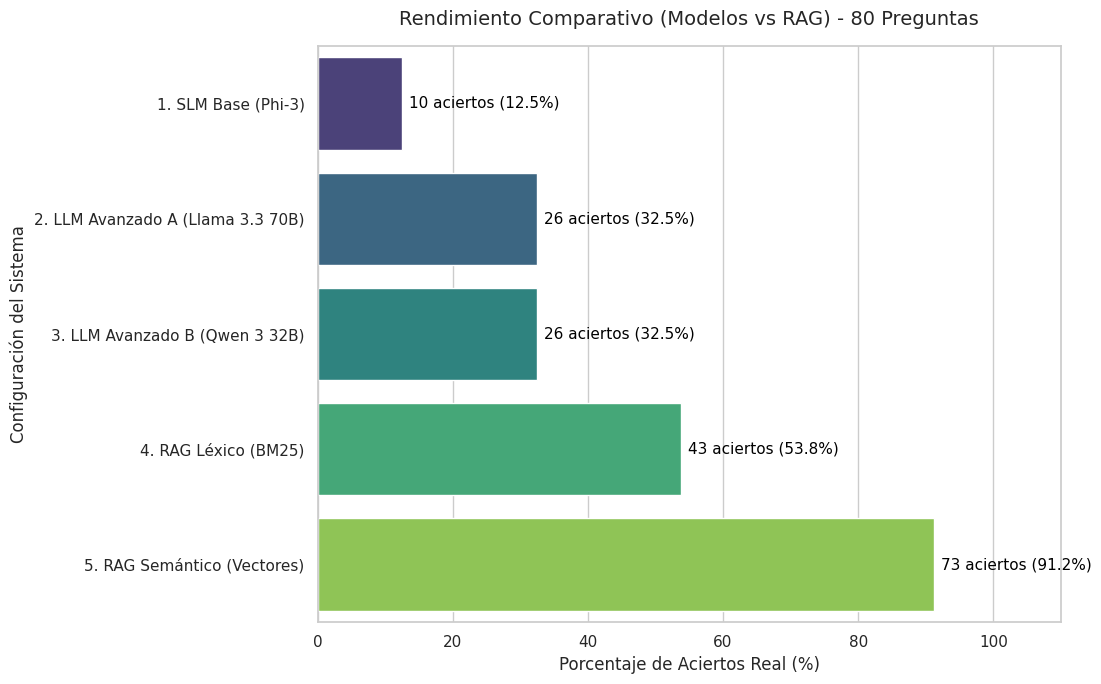

In [14]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Cargar el CSV ampliado (ya limpio y estandarizado)
ruta_final = "resultados_evaluacion_80_preguntas.csv"
df_final = pd.read_csv(ruta_final, sep=';')
df_final.columns = df_final.columns.str.strip()

print(f"Generando gráfico para {len(df_final)} preguntas evaluadas.")

# 2. Contar los aciertos de los 5 sistemas
aciertos = {
    "1. SLM Base (Phi-3)": (df_final['C1_Eval'].astype(str).str.strip().str.upper() == 'CORRECTO').sum(),
    "2. LLM Avanzado A (Llama 3.3 70B)": (df_final['C2_Eval'].astype(str).str.strip().str.upper() == 'CORRECTO').sum(),
    "3. LLM Avanzado B (Qwen 3 32B)": (df_final['C2B_Eval'].astype(str).str.strip().str.upper() == 'CORRECTO').sum(),
    "4. RAG Léxico (BM25)": (df_final['C3_Eval'].astype(str).str.strip().str.upper() == 'CORRECTO').sum(),
    "5. RAG Semántico (Vectores)": (df_final['C4_Eval'].astype(str).str.strip().str.upper() == 'CORRECTO').sum()
}

# 3. Preparar los datos
nombres = list(aciertos.keys())
valores = list(aciertos.values())
total_preguntas = len(df_final)
porcentajes = [(v / total_preguntas) * 100 for v in valores]

# 4. Crear el gráfico
plt.figure(figsize=(11, 7)) # Un poco más alto para que quepan bien las 5 barras
sns.set_theme(style="whitegrid")
ax = sns.barplot(x=porcentajes, y=nombres, palette="viridis")

# Etiquetas de datos
for p, val, perc in zip(ax.patches, valores, porcentajes):
    ax.annotate(f"{val} aciertos ({perc:.1f}%)", 
                (p.get_width() + 1, p.get_y() + p.get_height() / 2.), 
                ha='left', va='center', fontsize=11, color='black')

plt.xlim(0, 110)
plt.title(f'Rendimiento Comparativo (Modelos vs RAG) - {total_preguntas} Preguntas', fontsize=14, pad=15)
plt.xlabel('Porcentaje de Aciertos Real (%)', fontsize=12)
plt.ylabel('Configuración del Sistema', fontsize=12)
plt.tight_layout()

plt.savefig("grafico_rendimiento_5_modelos_tfg.png", dpi=300)
plt.show()